# **Data Preparation & Exploration**

## Objectives
- Prepare and explore the smartphone usage dataset.
- Perform descriptive statistics and exploratory data analysis (EDA) to understand relationships between smartphone usage behaviour, lifestyle factors, and smartphone addiction levels.

## Inputs
- Smartphone usage dataset
- Python libraries: pandas, numpy, matplotlib

## Outputs
- Descriptive statistics summary
- Visualisations (histograms, scatter plots, correlation analysis)
- Insights used to guide hypothesis testing in the next notebook

## Additional Comments
- This notebook focuses on data understanding and exploration. Statistical testing and modelling are performed in the next notebook.


---

# Section 1 - Extract, Transform and Loading the data

In [23]:
import pandas as pd
import numpy as np

In [24]:
df = pd.read_csv("../Data/Raw/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [25]:
df.shape
# Check how many rows and columns are in the dataset

(7500, 16)

In [26]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='str')

In [27]:
df.info()
# Check for missing values

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

In [28]:
df.duplicated().sum()
#check for duplicates

0

In [29]:
df = df.drop_duplicates()
#remove duplicates

In [30]:
df.duplicated().sum()
# Check for duplicates again to confirm they have been removed

0

In [31]:
df.isnull().sum()
# Check for missing values

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [36]:
df[df.isnull().any(axis=1)]

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN,0
11,TXN00012,U00012,27,Other,5.16,1.82,2.27,0.93,7.79,228,32,8.10,High,Yes,NaN,0
13,TXN00014,U00014,32,Male,4.09,1.74,1.35,3.74,5.54,76,16,4.77,High,Yes,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7447,TXN07448,U07448,20,Female,5.00,1.68,2.87,1.02,6.67,237,26,5.87,Medium,Yes,NaN,0
7454,TXN07455,U07455,29,Other,3.45,3.95,1.20,1.24,7.51,25,84,5.19,High,No,NaN,0
7457,TXN07458,U07458,29,Female,3.11,2.44,3.17,0.84,8.93,217,174,4.27,High,Yes,NaN,0
7481,TXN07482,U07482,29,Male,4.72,3.65,0.78,2.58,5.15,20,76,6.02,Medium,No,NaN,0


In [38]:
df = df.dropna(subset=["addiction_level"])
df.isnull().sum()
# Check for missing values again to confirm they have been removed

transaction_id             0
user_id                    0
age                        0
gender                     0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addiction_level            0
addicted_label             0
dtype: int64

In [32]:
df.dtypes
# Check data types of each column

transaction_id                 str
user_id                        str
age                          int64
gender                         str
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                   str
academic_work_impact           str
addiction_level                str
addicted_label               int64
dtype: object

In [42]:
df = df[[
    "age",
    "gender",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
    "stress_level",
    "academic_work_impact",
    "addiction_level",
    "addicted_label"
]]

In [43]:
df.to_csv("../Data/Clean/clean_smartphone_usage.csv", index=False)

---

# Section 2 - Core Statistical Concepts

## Descriptive Statistics

Descriptive statistics are used to summarise and describe sections of a dataset. In this project, descriptive statistics are used to analyse smartphone usage behaviour and addiction indicators.

### Mean (μ)

What is the mean?

- The mean is the average of a dataset and is calculated by summing all the values and dividing by the total number of observations in the sample. However, the mean can be affected by outliers, as unusually high or low values can make the mean higher or lower than it is.

In the context of the dataset:

- Variables such as daily screen time hours, social media hours, and gaming hours can be analysed using the mean to understand the typical level of smartphone usage among individuals. For example, calculating the average daily screen time helps show how much time users typically spend on their smartphones each day.


### Median

What is the median?

- The median is the middle value of a dataset when the data is arranged in ascending order. If there is an even number of observations, the median is calculated by taking the average of the two middle values. The median is less affected by extreme values, which makes it useful when the data contains outliers.

In the context of the dataset:

- If a small number of individuals spend extremely large amounts of time on their smartphones, this may increase the mean screen time significantly. In this case, the median daily screen time may better represent the typical usage behaviour of individuals in the dataset.


### Variance (σ²) and Standard Deviation (σ)

What is variance and standard deviation?

- Variance and standard deviation measure the spread or dispersion of values around the mean. Variance (σ²) measures the average squared difference between each value and the mean of the dataset. Standard deviation (σ) is the square root of variance and shows how far values typically vary from the mean in the same units as the data.

In the context of the dataset:

- A high standard deviation in daily screen time hours would indicate that smartphone usage varies widely between individuals. Some users may spend very little time on their devices, while others may spend many hours per day using their smartphones. Standard deviation can also help analyse variation in sleep hours or notifications received per day.


### Percentiles and Quartiles

What are percentiles and quartiles?

- Percentiles divide a dataset into equal parts and help show how values are distributed within the data. Quartiles are specific percentiles that divide the dataset into four equal sections. These include the first quartile (Q1) which represents the 25th percentile, the second quartile (Q2) which represents the 50th percentile and is the median, and the third quartile (Q3) which represents the 75th percentile.

- The interquartile range (IQR) measures the spread of the middle 50 percent of the dataset and is calculated using the formula:

IQR = Q3 − Q1

- The IQR is useful because it is less affected by extreme values and provides a clearer understanding of the spread of the data.

In the context of the dataset:

- Percentiles can be used to analyse the distribution of daily screen time or app opens per day. For example, if the middle 50 percent of users spend between 3 and 6 hours on their smartphones each day, this suggests that most individuals fall within this usage range while a smaller number of users exhibit very high or very low usage patterns.



---

## Probability & Distributions

Probability measures how likely something is to happen. It ranges from 0 to 1, where 0 means the event cannot happen and 1 means the event will definitely happen.

### Probability Basics

- P(event) ranges from 0 (impossible) to 1 (certain)
- P(A or B) = P(A) + P(B) − P(A and B)
- P(A and B) = P(A) × P(B|A)

In the context of the dataset:
- If 40 percent of individuals in the dataset are classified as addicted to smartphone usage, then the probability of randomly selecting an addicted user would be P(addicted) = 0.40. The probability of selecting a non-addicted user would be P(not addicted) = 0.60.


#### Normal Distribution (Gaussian)

- A normal distribution is a bell-shaped and symmetrical distribution.
- It is defined by the mean (μ) and standard deviation (σ).
- About 68 percent of data falls within ±1σ of the mean.
- About 95 percent of data falls within ±2σ of the mean.
- About 99.7 percent of data falls within ±3σ of the mean.

In the context of the dataset:
- Variables such as daily screen time hours or sleep hours may follow a roughly normal distribution if most individuals cluster around an average usage level while fewer individuals have extremely high or extremely low values.


### Skewness

- Right-skewed (positive skew): the tail of the distribution extends to the right, meaning the mean is greater than the median.
- Left-skewed (negative skew): the tail of the distribution extends to the left, meaning the mean is less than the median.
- Skewness helps show whether data is symmetrical or unevenly distributed.

In the context of the dataset:
- Smartphone usage behaviour may be right-skewed because most users may have moderate screen time while a smaller number of individuals may spend extremely high amounts of time on their smartphones.


### Central Limit Theorem (CLT)

What is the Central Limit Theorem?
- The Central Limit Theorem states that as the sample size increases, the distribution of the sample mean approaches a normal distribution regardless of the shape of the population distribution. This generally applies when the sample size is 30 or more observations.

In the context of the dataset:
- Since the dataset contains 7,500 observations, the Central Limit Theorem allows statistical analysis such as hypothesis testing to be applied even if the original data is not perfectly normally distributed.


---

## Hypothesis Testing Framework

Hypothesis testing provides a structured way to make conclusions about data using statistical evidence. It helps determine whether relationships observed in the dataset are statistically significant or likely to have occurred by chance.

### Null Hypothesis (H₀)

- The null hypothesis represents the default assumption that there is no relationship or no difference between variables.

In the context of the dataset:

- An example of a null hypothesis is that daily screen time has no relationship with smartphone addiction level.


### Alternative Hypothesis (H₁)

- The alternative hypothesis represents the claim that there is a relationship or difference between variables.

In the context of the dataset:

- For example, the alternative hypothesis may suggest that individuals who spend more time on their smartphones tend to have higher addiction levels.


### P-Value

- A p-value measures the probability of obtaining results at least as extreme as those observed, assuming that the null hypothesis is true.
- A small p-value (typically less than 0.05) suggests strong evidence against the null hypothesis.
- A large p-value suggests that there is not enough evidence to reject the null hypothesis.

In the context of the dataset:
- The p-value will help determine whether relationships between variables such as screen time, social media usage, sleep hours, and addiction level are statistically significant.


### Significance Level (α)

- The significance level represents the threshold used to decide whether the null hypothesis should be rejected. It is commonly set at α = 0.05.

- If the p-value is less than the significance level, the null hypothesis is rejected. If the p-value is greater than or equal to the significance level, the null hypothesis cannot be rejected.


### Confidence Intervals

- A confidence interval provides a range of values that is likely to contain the true population parameter. A 95 percent confidence interval means that we are 95 percent confident that the true value lies within the calculated range.

In the context of the dataset:
- Confidence intervals can be used to estimate the range in which the true relationship between smartphone usage behaviour and addiction level may lie.

---

## Types of Statistical Tests Used in This Analysis

The following statistical tests are used to analyse relationships within the dataset and evaluate the project hypotheses.

### Spearman Correlation

- Spearman correlation is a statistical test used to measure the strength and direction of the relationship between two variables. It is a non-parametric test, which means it does not assume that the data follows a normal distribution.
- The correlation coefficient ranges from -1 to 1.
- A value close to 1 indicates a strong positive relationship.
- A value close to -1 indicates a strong negative relationship.
- A value close to 0 indicates little or no relationship.

In the context of the dataset:

- Spearman correlation can be used to examine the relationship between daily screen time, social media hours, and addiction level.


### Welch’s t-test

- Welch’s t-test is a statistical test used to compare the mean values of two independent groups. It is particularly useful when the groups may have unequal variances or different sample sizes.

In the context of the dataset:

- Welch’s t-test can be used to compare the average addiction level between individuals with high daily screen time and those with lower daily screen time.


### Analysis of Variance (ANOVA)

- Analysis of Variance (ANOVA) is a statistical test used to compare the mean values of three or more groups.

In the context of the dataset:

- ANOVA can be used to compare the average addiction levels across different stress levels such as low, medium, and high.

---

# Section 3 - Descriptive Stats + EDA

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,6681.0,NaN,NaN,NaN,26.580602,5.201722,18.0,22.0,27.0,31.0,35.0
gender,6681,3,Male,2284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_screen_time_hours,6681.0,NaN,NaN,NaN,7.864862,2.516355,3.01,5.92,8.01,10.05,12.0
social_media_hours,6681.0,NaN,NaN,NaN,3.40009,1.594324,0.5,2.03,3.51,4.79,6.0
gaming_hours,6681.0,NaN,NaN,NaN,2.015176,1.146717,0.0,1.01,2.05,2.99,4.0
work_study_hours,6681.0,NaN,NaN,NaN,3.240322,1.599141,0.5,1.84,3.22,4.64,6.0
sleep_hours,6681.0,NaN,NaN,NaN,6.744914,1.285371,4.5,5.64,6.73,7.86,9.0
notifications_per_day,6681.0,NaN,NaN,NaN,134.244275,66.50262,20.0,76.0,134.0,191.0,250.0
app_opens_per_day,6681.0,NaN,NaN,NaN,97.921269,48.353895,15.0,56.0,98.0,140.0,180.0
weekend_screen_time,6681.0,NaN,NaN,NaN,9.613552,2.623642,3.63,7.57,9.75,11.75,14.88


### Key Descriptive Statistics in the context of the dataset

- The smartphone usage dataset contains 6,681 individuals with variables describing smartphone usage behaviour, lifestyle factors, and addiction indicators.

The descriptive statistics show that the average age of individuals in the dataset is approximately 26.6 years, with ages ranging from 18 to 35. The average daily screen time is around 7.86 hours, suggesting that smartphone usage occupies a large portion of the day for many individuals.

The dataset also shows that individuals spend an average of approximately 3.4 hours per day on social media and around 2 hours per day gaming. The average sleep duration is approximately 6.74 hours, which provides useful context when analysing how smartphone behaviour may relate to sleep patterns.

These statistics confirm that the dataset values appear reasonable and suitable for further analysis of smartphone usage behaviour and addiction patterns.

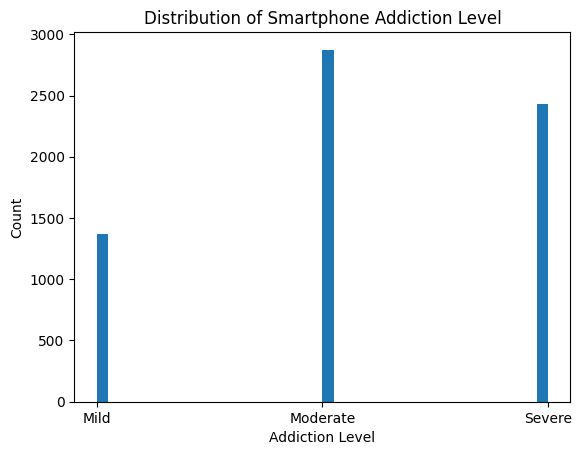

In [45]:
plt.figure()
plt.hist(df["addiction_level"], bins=40)
plt.title("Distribution of Smartphone Addiction Level")
plt.xlabel("Addiction Level")
plt.ylabel("Count")
plt.show()

### Addiction level distribution in the context of the dataset

- 
Addiction Level Distribution in the context of the dataset

The histogram shows how smartphone addiction levels are distributed across individuals in the dataset.

Most individuals fall within the moderate addiction category, with fewer individuals classified as mild or severe. This suggests that moderate levels of smartphone dependence are common within the dataset.

Understanding the distribution of addiction levels is useful for identifying how widespread higher levels of smartphone addiction are within the population being studied.

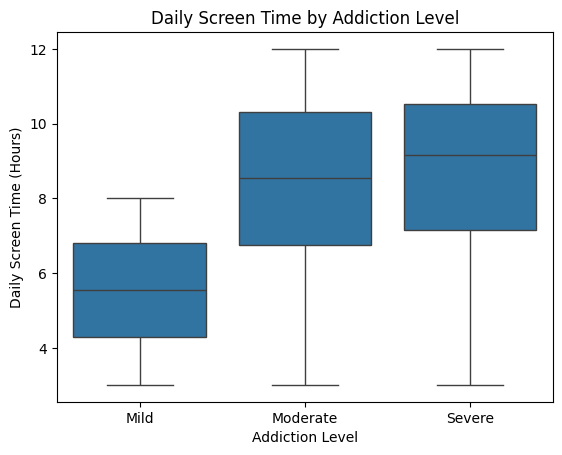

In [52]:
plt.figure()
sns.boxplot(x="addiction_level", y="daily_screen_time_hours", data=df)
plt.title("Daily Screen Time by Addiction Level")
plt.xlabel("Addiction Level")
plt.ylabel("Daily Screen Time (Hours)")
plt.show()

Daily Screen Time vs Addiction Level in the context of the dataset

The boxplot shows the relationship between daily smartphone screen time and addiction level.

Individuals classified with severe addiction tend to have higher daily screen time compared to those with mild addiction levels. The median screen time increases across the addiction categories from mild to moderate to severe.

This suggests that higher daily smartphone usage may be associated with higher levels of smartphone addiction.

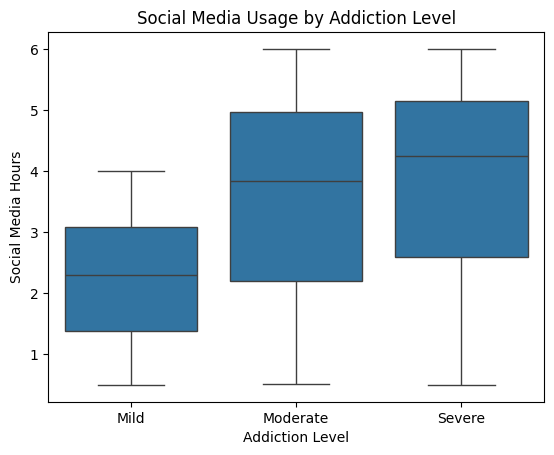

In [53]:
plt.figure()
sns.boxplot(x="addiction_level", y="social_media_hours", data=df)
plt.title("Social Media Usage by Addiction Level")
plt.xlabel("Addiction Level")
plt.ylabel("Social Media Hours")
plt.show()

Social Media Usage vs Addiction Level in the context of the dataset

The boxplot shows how time spent on social media varies across different addiction levels.

Individuals with higher addiction levels tend to spend more time on social media compared to individuals with mild addiction levels. The median social media usage increases as addiction level increases.

This suggests that increased social media usage may be associated with higher smartphone addiction levels.

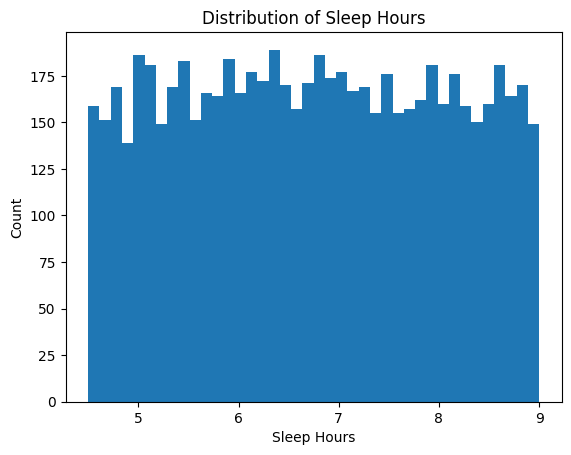

In [49]:
plt.figure()
plt.hist(df["sleep_hours"], bins=40)
plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Count")
plt.show()

Sleep Hours Distribution in the context of the dataset

The histogram shows the distribution of sleep duration among individuals in the dataset.

Most individuals appear to sleep between approximately 5 and 8 hours per night. This suggests that sleep duration varies moderately across the dataset.

Sleep patterns are important to consider when analysing smartphone usage behaviour, as excessive smartphone use may influence sleep habits and overall wellbeing.

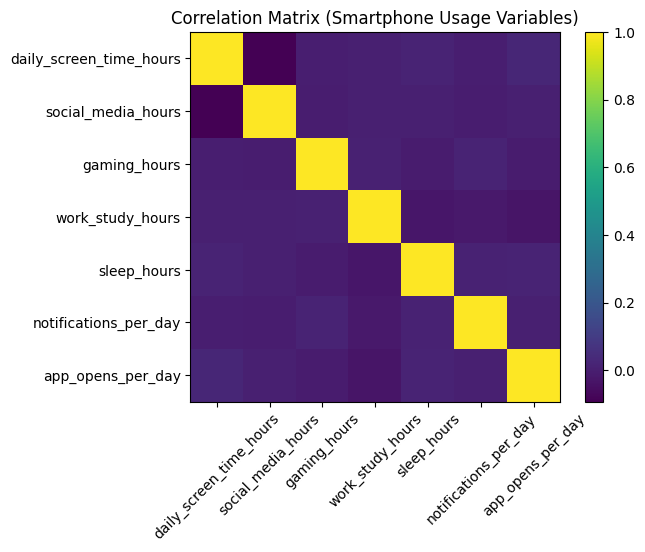

,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day
daily_screen_time_hours,1.000000,-0.092602,-0.000492,0.005023,0.014112,0.000989,0.025465
social_media_hours,-0.092602,1.000000,-0.003062,0.004201,0.004473,-0.007034,0.002754
gaming_hours,-0.000492,-0.003062,1.000000,0.007245,-0.008201,0.016110,-0.007268
work_study_hours,0.005023,0.004201,0.007245,1.000000,-0.027805,-0.016364,-0.028972
sleep_hours,0.014112,0.004473,-0.008201,-0.027805,1.000000,0.013852,0.017247
notifications_per_day,0.000989,-0.007034,0.016110,-0.016364,0.013852,1.000000,0.003222
app_opens_per_day,0.025465,0.002754,-0.007268,-0.028972,0.017247,0.003222,1.000000


In [51]:
numeric_cols = [
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day"
]

corr = df[numeric_cols].corr()

plt.figure()
plt.imshow(corr, interpolation="nearest")
plt.title("Correlation Matrix (Smartphone Usage Variables)")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar()
plt.show()

corr

Correlation Matrix in the context of the dataset

The correlation matrix shows how different smartphone usage variables relate to each other.

Most variables show weak correlations with one another, suggesting that smartphone behaviour is influenced by multiple factors rather than a single dominant variable.

Variables such as daily screen time, social media usage, and gaming hours measure different aspects of smartphone behaviour, while variables such as notifications per day and app opens per day capture device interaction frequency.

Overall, the correlation matrix provides an overview of relationships between smartphone usage behaviours and helps guide further statistical testing in the next stage of the analysis.